# **Práctica 1: Análisis exploratorio de dataset**
### Introducción a la Ciencia de Datos 
*Alumno: Norman O. Guzmán Chaboya*

La presente práctica tiene como objetivo realizar un análisis exploratorio sobre un conjunto de datos, detallando los siguientes atributos de este:
* Contexto y Procedencia.
* Estructura (y su verificación).
* Análisis de calidad de los datos.
* Sobre una selcción de atributos particulares:
    * Análisis univariado.
    * Análisis bivariado.
    * Análisis/vista multivariado(a).
* Hallazgos.
* Preguntas por contestar acerca del conjunto de datos.
* Problemas por superar en materia de datos.

Primeramente, importamos las bibliotecas necesarias para este proyecto, particularmente `pandas` nos hará posible explorar los contenidos del dataset seleccionado, y manipular los datos de tal manera que puedan darnos información organizada y presta para ser visualizada a través de `matplotlib` o `seaborn`

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mp_dates
import matplotlib.ticker as mticker
plt.style.use('bmh')
import seaborn as sns

Con el fin de visualizar simultáneamente dos o más tablas (como se verá más adelante en este notebook), se reuitlizó la función `display()` definida en el notebook [Combining Datasets: Concat and Append](https://github.com/husseinlopez/PythonDataScienceHandbook/blob/master/notebooks_v1/03.06-Concat-And-Append.ipynb) de la serie correspondiente al libro *Python Data Science Handbook* de Jake VanderPlas, la cual resulta muy útil para discutir sobre el contenido de varios *dataframes*:

In [2]:
class display(object):
    # Función para observar simultáneamente múltiples objetos HTML
    template = """<div style="float: left; padding: 10px;">
    <p style='font-family:"Courier New", Courier, monospace'>{0}</p>{1}
    </div>"""
    def __init__(self, *args):
        self.args = args
        
    def _repr_html_(self):
        return '\n'.join(self.template.format(a, eval(a)._repr_html_())
                         for a in self.args)
    
    def __repr__(self):
        return '\n\n'.join(a + '\n' + repr(eval(a))
                           for a in self.args)

## Conjunto de Datos

#### Contexto y Procedencia
El *dataset* seleccionado se titula [Accidentes de Tránsito Terrestre en Zonas Urbanas y Suburbanas (ATUS)](https://www.inegi.org.mx/programas/accidentes/#datos_abiertos) y fue publicado por el INEGI en julio de 2026. Este contiene una antología de datos de accidentes de tránsito registrados por los gobiernos municipales en cada entidad del país. Cabe destacar que la información de los accidentes recabados aquí solo corresponde aquellos ocurridos en zonas no federales de México, e incluye registros pertinentes a los a años comprendidos entre 1997 y 2025.



Para descargarlo, se puede hacer a través del siguiente link: \
https://www.inegi.org.mx/contenidos/programas/accidentes/datosabiertos/conjunto_de_datos_atus_anual_csv.zip

Por cuestiones de almanecenamiento y efectos prácticos de esta actividad, solamente se tomaron los datos correspondientes al año 2025. Como se podrá apreciar al analizar a detalle la tabla correspondiente, cada año contiene entre de 200 mil y 400 mil registros para cada año contemplado por el INEGI, por lo que se optó por concentrarse únicamente en la información recabada durante el último año.

#### Licencia
Los datos compratidos por el INEGI están adscritos a [Norma Técnica para el Acceso y Publicación de Datos Abiertos de la Información Estadística y Geográfica de Interés Nacional](https://www.snieg.mx/Documentos/Normatividad/Vigente/FT_Tecnica/FT_DA_IEG_IN.pdf), la cual estipula que los conjuntos de datos eleborados por esta institución esta puestos a disposición del público en general como "Datos Abiertos", lo que implica un fácil acceso, uso, consulta, reutilización y redistribución para cualquier fin.

Para cargar la tabla, utilizamos la función de panda apropiada:

In [3]:
data_df = pd.read_csv('./data/atus_anual_2025.csv')

Y se muestra de la siguiente manera:

In [4]:
data_df

,COBERTURA,CVEGEO,CVE_ENT,CVE_MUN,ANIO,MES,ID_HORA,ID_MINUTO,ID_DIA,DIASEMANA,...,PEATMUERTO,PEATHERIDO,CICLMUERTO,CICLHERIDO,OTROMUERTO,OTROHERIDO,NEMUERTO,NEHERIDO,CLASACC,ESTATUS
0,Municipal,1001,1,1,2025,1,3,30,1,Miércoles,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Definitivas
1,Municipal,1001,1,1,2025,1,8,15,1,Miércoles,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Definitivas
2,Municipal,1001,1,1,2025,1,8,35,1,Miércoles,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Definitivas
3,Municipal,1001,1,1,2025,1,9,35,1,Miércoles,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Definitivas
4,Municipal,1001,1,1,2025,1,13,5,1,Miércoles,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Definitivas
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
380386,Municipal,32056,32,56,2025,12,22,43,26,Viernes,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Definitivas
380387,Municipal,32056,32,56,2025,12,3,42,27,Sábado,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Definitivas
380388,Municipal,32056,32,56,2025,12,22,0,27,Sábado,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Definitivas
380389,Municipal,32056,32,56,2025,12,1,45,28,Domingo,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Definitivas


A grandes rasgos, se sabe que la tabla contine un total de 380,391 registros (denotado por el número de filas), para los cuáles se han reportado un total de 46 atributos. Podemos utilizar la función/atributo del *dataframe* para ver rápidamente el listado de columnas y leer cuáles son todos los atributos que incluye la tabla:

In [5]:
print(data_df.columns)

Index(['COBERTURA', 'CVEGEO', 'CVE_ENT', 'CVE_MUN', 'ANIO', 'MES', 'ID_HORA',
       'ID_MINUTO', 'ID_DIA', 'DIASEMANA', 'URBANA', 'SUBURBANA', 'TIPACCID',
       'AUTOMOVIL', 'CAMPASAJ', 'MICROBUS', 'PASCAMION', 'OMNIBUS', 'TRANVIA',
       'CAMIONETA', 'CAMION', 'TRACTOR', 'FERROCARRI', 'MOTOCICLET',
       'BICICLETA', 'OTROVEHIC', 'CAUSAACCI', 'CAPAROD', 'SEXO', 'ALIENTO',
       'CINTURON', 'ID_EDAD', 'CONDMUERTO', 'CONDHERIDO', 'PASAMUERTO',
       'PASAHERIDO', 'PEATMUERTO', 'PEATHERIDO', 'CICLMUERTO', 'CICLHERIDO',
       'OTROMUERTO', 'OTROHERIDO', 'NEMUERTO', 'NEHERIDO', 'CLASACC',
       'ESTATUS'],
      dtype='str')


In [6]:
print(data_df.dtypes)

COBERTURA       str
CVEGEO        int64
CVE_ENT       int64
CVE_MUN       int64
ANIO          int64
MES           int64
ID_HORA       int64
ID_MINUTO     int64
ID_DIA        int64
DIASEMANA       str
URBANA          str
SUBURBANA       str
TIPACCID        str
AUTOMOVIL     int64
CAMPASAJ      int64
MICROBUS      int64
PASCAMION     int64
OMNIBUS       int64
TRANVIA       int64
CAMIONETA     int64
CAMION        int64
TRACTOR       int64
FERROCARRI    int64
MOTOCICLET    int64
BICICLETA     int64
OTROVEHIC     int64
CAUSAACCI       str
CAPAROD         str
SEXO            str
ALIENTO         str
CINTURON        str
ID_EDAD       int64
CONDMUERTO    int64
CONDHERIDO    int64
PASAMUERTO    int64
PASAHERIDO    int64
PEATMUERTO    int64
PEATHERIDO    int64
CICLMUERTO    int64
CICLHERIDO    int64
OTROMUERTO    int64
OTROHERIDO    int64
NEMUERTO      int64
NEHERIDO      int64
CLASACC         str
ESTATUS         str
dtype: object


#### Estructura, Atributos y su calidad
A continuación se enlistan los atributos contenidos en la tabla, y agrupados de acuerdo a la dimensión a laz que pertenece con respecto al accidente. Esta descirpción es un resumen de lo descrito por el Diccionario de Datos ([diccionario_de_datos_atus_anual_1997_2025.csv](./diccionario_de_datos_atus_anual_1997_2025.csv)) adjunto al conjunto de datos ATUS:

##### Identificación geográfica y temporal


- `COBERTURA`: Área geográfica a la que están referidos los indicadores (varchar, 200)
- `CVEGEO`: Clave geoestadística (char, 2), rango 01001 a 32058
- `ID_ENTIDAD`: Clave de la entidad federativa (char, 2), 01-32
- `ID_MUNICIPIO`: Clave del municipio (char, 3), 001-999
- `ANIO`: Año en que ocurrió el accidente (int), 1997-2025
- `MES`: Mes de referencia (varchar, 2), 01-12
- `ID_DIA`: Día del mes (varchar, 2), 01-31 (32 = no especificado)
- `DIASEMANA`: Día de la semana (varchar, 20), Lunes-Domingo, Certificado cero, No especificado
- `ID_HORA`: Hora del accidente (int), 0-23 (99 = no especificada)
- `ID_MINUTO`: Minuto del accidente (int), 0-59 (99 = no especificado)

##### Ubicación


- `URBANA`: Tipo de accidente en zona urbana (varchar, 50)
- `SUBURBANA`: Tipo de accidente en zona suburbana (varchar, 50)
- `CAPAROD`: Superficie de rodamiento (varchar, 50)

Podemos ver la cardinalidad de estos atributos tal cual y como fueron reportados en el archivo `.csv` agrupando por su respectiva columna:

In [7]:
# Utilizamos la función previamente discutida, la cual nos permite ver simultaneamente
# los 3 dataframes seleccionados
df_urbana = pd.DataFrame({'URBANA': data_df.loc[:, 'URBANA'].unique(),
                          'total': data_df.loc[:, 'URBANA'].value_counts().values}) # utilizando .unique(), se enlistan los casos únicos de la columna
df_suburbana = pd.DataFrame({'SUBURBANA': data_df.loc[:, 'SUBURBANA'].unique(), 
                            'total': data_df.loc[:, 'SUBURBANA'].value_counts().values}) # Zona suburbana
df_caparod = pd.DataFrame({'CAPAROD': data_df.loc[:, 'CAPAROD'].unique(),
                            'total': data_df.loc[:, 'CAPAROD'].value_counts().values}) # Superficie de rodamiento

display('df_urbana', 'df_suburbana', 'df_caparod') # Finalmente utilizamos display()

,URBANA,total
0,Accidente en no intersección,257149
1,Accidente en intersección,96014
2,Sin accidente en esta zona,27228
,SUBURBANA,total
0,Sin accidente en esta zona,353163
1,Accidente en carretera estatal,18295
2,Accidentes en otro camino,6204
3,Accidente en camino rural,2729
,CAPAROD,total
0,Pavimentada,374672


##### Características del accidente

- `TIPACCID`: Tipo de accidente (varchar, 100)
- `CAUSAACCI`: Causa presunta (varchar, 50)
- `CLASACC`: Clasificación de gravedad (varchar, 50)
- `ESTATUS`: Estatus de las cifras (varchar, 20)

In [8]:
df_tipaccid = pd.DataFrame({'TIPACCID': data_df.loc[:, 'TIPACCID'].unique(),
                           'total': data_df.loc[:, 'TIPACCID'].value_counts().values}) # Tipo de Accidente
df_causaacci = pd.DataFrame({'CAUSAACCI': data_df.loc[:, 'CAUSAACCI'].unique(),
                            'total': data_df.loc[:, 'CAUSAACCI'].value_counts().values}) # Causa del Accidente
df_clasacc = pd.DataFrame({'CLASACC': data_df.loc[:, 'CLASACC'].unique(),
                          'total': data_df.loc[:, 'CLASACC'].value_counts().values}) # Clasificación del Accidente
df_estatus  = pd.DataFrame({'ESTATUS': data_df.loc[:, 'ESTATUS'].unique(),
                           'total': data_df.loc[:, 'ESTATUS'].value_counts().values}) # Clasificación del Accidente

display('df_tipaccid', 'df_causaacci', 'df_clasacc', 'df_estatus')

,TIPACCID,total
0,Colisión con vehículo automotor,222241
1,Colisión con objeto fijo,68505
2,Colisión con motocicleta,43336
3,Colisión con peatón (atropellamiento),15412
4,Volcadura,10612
5,Colisión con ciclista,10000
6,Salida del camino,3999
7,Colisión con ferrocarril,2505
8,Otro,2142
9,Caída de pasajero,936


##### Vehículos involucrados (conteo por tipo, int, 0-9)

- `AUTOMOVIL`: Automóvil (hasta 7 asientos)
- `CAMPASAJ`: Camioneta de pasajeros (8-15 asientos)
- `MICROBUS`: Microbús (16-20 asientos)
- `PASCAMION`: Camión urbano de pasajeros (21-29 asientos)
- `OMNIBUS`: Ómnibus (30+ asientos)
- `TRANVIA`: Tren eléctrico o trolebús
- `CAMIONETA`: Camioneta de carga
- `CAMION`: Camión de carga
- `TRACTOR`: Tractor con o sin remolque
- `FERROCARRI`: Ferrocarril
- `MOTOCICLET`: Motocicleta
- `BICICLETA`: Bicicleta
- `OTROVEHIC`: Otro (ambulancias, grúas, tractores agrícolas, etc.)

 ##### Datos del conductor responsable

- `SEXO`: Género (varchar, 20), Se fugó, Hombre, Mujer, Certificado cero
- `ALIENTO`: Sobriedad (varchar, 20), Sí, No, Se ignora, Certificado cero
- `CINTURON`: Uso de cinturón de seguridad (varchar, 20), Sí, No, Se ignora, Certificado cero
- `ID_EDAD`: Edad (varchar, 2), 12-98 (0 = se fugó, 99 = se ignora)

In [9]:
df_sexo = pd.DataFrame({'SEXO': data_df.loc[:, 'SEXO'].unique(),
                       'total': data_df.loc[:, 'SEXO'].value_counts().values})
df_aliento = pd.DataFrame({'ALIENTO': data_df.loc[:, 'ALIENTO'].unique(),
                          'total': data_df.loc[:, 'ALIENTO'].value_counts().values})
df_cinturon = pd.DataFrame({'CINTURON': data_df.loc[:, 'CINTURON'].unique(),
                           'total': data_df.loc[:, 'CINTURON'].value_counts().values})
display('df_sexo', 'df_aliento', 'df_cinturon')

,SEXO,total
0,Hombre,283789
1,Mujer,61683
2,Se fugó,34919
,ALIENTO,total
0,Se ignora,229476
1,Sí,134698
2,No,16217
,CINTURON,total
0,Se ignora,294580
1,No,44147


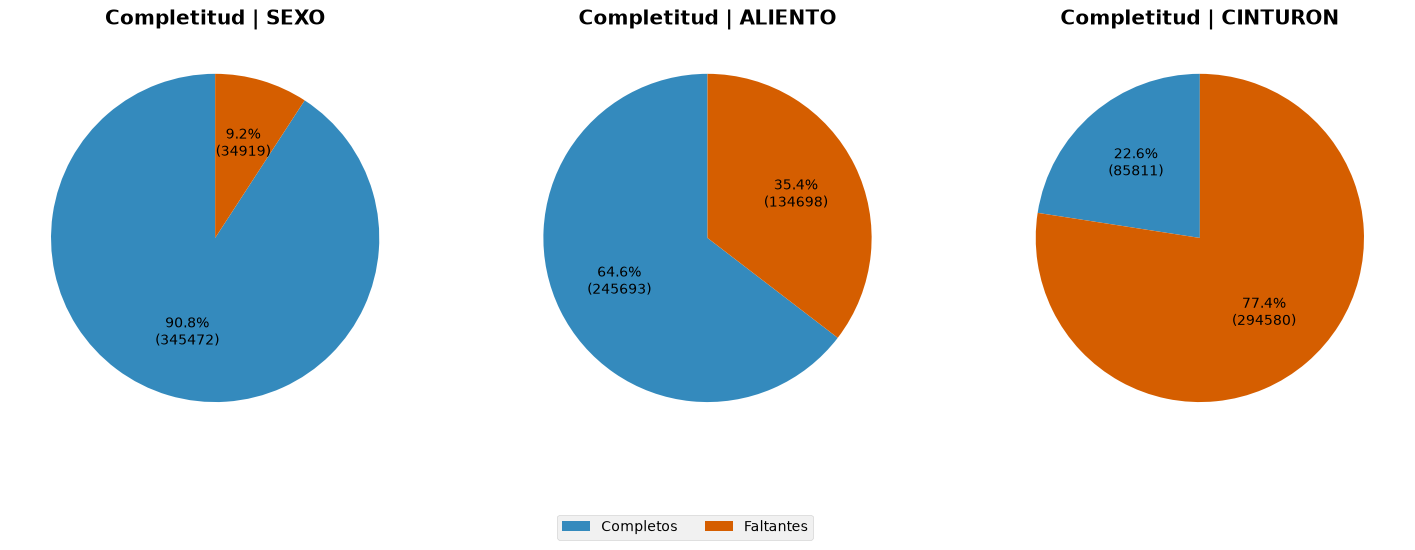

In [10]:
key = ['SEXO', 'ALIENTO', 'CINTURON']
null_key = ['Se fugó', 'Se ignora', 'Se ignora']
with plt.style.context('bmh'):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    for i in range(3):
        faltantes = len(data_df[data_df[key[i]] == null_key[i]])
        completos = len(data_df[data_df[key[i]] != null_key[i]])
        total = completos + faltantes

        wedges, texts, autotexts = axes[i].pie(
            [completos, faltantes],
            autopct=lambda pct, total=total: f'{pct:.1f}%\n({int(round(pct/100*total))})',
            colors=['#348ABD', '#D55E00'],
            startangle=90
        )
        axes[i].set_title(f'Completitud | {key[i]}', fontweight='bold')

    fig.legend(
        wedges, ['Completos', 'Faltantes'],
        loc='lower center', ncol=2, bbox_to_anchor=(0.5, -0.02)
    )

        
    plt.show()

##### Víctimas (muertos y heridos por categoría, int, 0-99)

- `CONDMUERTO` / `CONDHERIDO`: Conductores muertos / heridos
- `PASAMUERTO` / `PASAHERIDO`: Pasajeros muertos / heridos
- `PEATMUERTO` / `PEATHERIDO`: Peatones muertos / heridos
- `CICLMUERTO` / `CICLHERIDO`: Ciclistas muertos / heridos
- `OTROMUERTO` / `OTROHERIDO`: Otros involucrados muertos / heridos (personas en inmuebles, mantenimiento, construcción, etc.)
- `NEMUERTO` / `NEHERIDO`: Víctimas muertas / heridas no clasificadas por la fuente

##### Limpieza 

Para reducir las dimensiones de la tabla, he optado por fusionar los datos númericos/temporales en una sola varibale en formato de *timestamp*, dejando únicamente la variable ordinal `DIASEMANA`. Primeramente, verifico la completitud de los datos temporales que de acuerdo al diccionario, pudieran estar reportados como faltantes de acuerdo a su respectivo código validado:

In [11]:
# Primeramente, verifico la completitud de los datos temporales que de acuerdo al diccionario 
#print(np.sort(data_df['ID_HORA'].unique()))
for col in [[32, 'ID_DIA'], [99, 'ID_MINUTO'], [99,'ID_HORA']]:
    # Agrupamos y enlistamos vals. únicos
    print (f"¿Se encontró un valor no reportado para '{col[1]}' (código {col[0]})?: {col[0] in data_df[col[1]].unique()}") 

¿Se encontró un valor no reportado para 'ID_DIA' (código 32)?: False
¿Se encontró un valor no reportado para 'ID_MINUTO' (código 99)?: False
¿Se encontró un valor no reportado para 'ID_HORA' (código 99)?: False


Puesto que no se encontraron faltantes para ninguno de los atributos necesarios, no se requerirá hacer ninguna otra operación como pudiera ser imputación o elimnacion de registros incompletos.
\
\
Lo siguiente es fusionar los datos númericos/temporales en un *timestamp*:


In [12]:
# fusionamos las series en otra de tipo datetime
date_series = pd.to_datetime({
    'day': data_df['ID_DIA'],       # Dia
    'month': data_df['MES'],        # Mes
    'year': data_df['ANIO'],        # Año
    'hour': data_df['ID_HORA'],     # Hora
    'minute': data_df['ID_MINUTO'], # Minuto
})

loc = data_df.columns.get_loc('ANIO') 
data_df.insert(loc, "FECHA", date_series) # Insertamos justo en la posición que tiene 'ANIO'

#Eliminamos las columnas/atributos que ya no necesitaremos más
data_df = data_df.drop(columns=['ID_DIA', 'MES', 'ANIO', 'ID_HORA', 'ID_MINUTO'])

data_df.head(1)

,COBERTURA,CVEGEO,CVE_ENT,CVE_MUN,FECHA,DIASEMANA,URBANA,SUBURBANA,TIPACCID,AUTOMOVIL,...,PEATMUERTO,PEATHERIDO,CICLMUERTO,CICLHERIDO,OTROMUERTO,OTROHERIDO,NEMUERTO,NEHERIDO,CLASACC,ESTATUS
0,Municipal,1001,1,1,2025-01-01 03:30:00,Miércoles,Accidente en no intersección,Sin accidente en esta zona,Colisión con vehículo automotor,2,...,0,0,0,0,0,0,0,0,Sólo daños,Cifras Definitivas


##### Calidad 

In [13]:
cols_vehiculo = ['AUTOMOVIL', 'CAMPASAJ', 'MICROBUS', 'PASCAMION', 'OMNIBUS', 
               'TRANVIA','CAMIONETA', 'CAMION', 'TRACTOR', 'FERROCARRI', 
               'MOTOCICLET', 'BICICLETA', 'OTROVEHIC']
data_df[cols_vehiculo].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
AUTOMOVIL,380391.0,1.15,0.76,0.0,1.0,1.0,2.0,8.0
CAMPASAJ,380391.0,0.22,0.48,0.0,0.0,0.0,0.0,6.0
MICROBUS,380391.0,0.00,0.07,0.0,0.0,0.0,0.0,3.0
PASCAMION,380391.0,0.04,0.20,0.0,0.0,0.0,0.0,3.0
OMNIBUS,380391.0,0.00,0.06,0.0,0.0,0.0,0.0,2.0
TRANVIA,380391.0,0.00,0.02,0.0,0.0,0.0,0.0,1.0
CAMIONETA,380391.0,0.13,0.36,0.0,0.0,0.0,0.0,4.0
CAMION,380391.0,0.04,0.20,0.0,0.0,0.0,0.0,4.0
TRACTOR,380391.0,0.03,0.17,0.0,0.0,0.0,0.0,3.0
FERROCARRI,380391.0,0.00,0.03,0.0,0.0,0.0,0.0,2.0


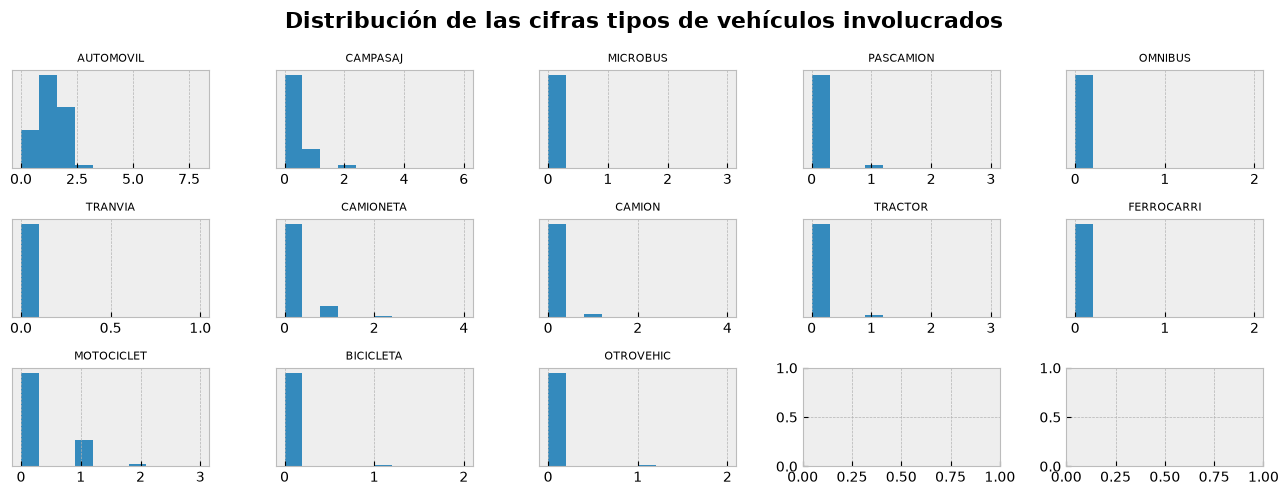

In [14]:
fig, axes = plt.subplots(3, 5, figsize=(13, 5))

with plt.style.context('bmh'):
    for ax, col in zip(axes.ravel(), cols_vehiculo):
        ax.hist(data_df[col], bins=10)
        ax.set_title(col, fontsize=8)
        ax.set_yticks([])
    
    fig.suptitle("Distribución de las cifras tipos de vehículos involucrados",
                 fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()

In [15]:
cols_cifras = ['CONDMUERTO', 'CONDHERIDO', 'PASAMUERTO', 'PASAHERIDO', 
               'PEATMUERTO', 'PEATHERIDO', 'CICLMUERTO', 'CICLHERIDO', 
               'OTROMUERTO', 'OTROHERIDO', 'NEMUERTO', 'NEHERIDO']
data_df[cols_cifras].describe().round(2).T

,count,mean,std,min,25%,50%,75%,max
CONDMUERTO,380391.0,0.01,0.08,0.0,0.0,0.0,0.0,3.0
CONDHERIDO,380391.0,0.12,0.35,0.0,0.0,0.0,0.0,15.0
PASAMUERTO,380391.0,0.00,0.07,0.0,0.0,0.0,0.0,15.0
PASAHERIDO,380391.0,0.07,0.41,0.0,0.0,0.0,0.0,40.0
PEATMUERTO,380391.0,0.00,0.05,0.0,0.0,0.0,0.0,3.0
PEATHERIDO,380391.0,0.03,0.18,0.0,0.0,0.0,0.0,11.0
CICLMUERTO,380391.0,0.00,0.02,0.0,0.0,0.0,0.0,1.0
CICLHERIDO,380391.0,0.01,0.08,0.0,0.0,0.0,0.0,3.0
OTROMUERTO,380391.0,0.00,0.01,0.0,0.0,0.0,0.0,2.0
OTROHERIDO,380391.0,0.00,0.02,0.0,0.0,0.0,0.0,2.0


In [44]:
muerto_cols = ['CONDMUERTO', 'PASAMUERTO', 'PEATMUERTO', 'CICLMUERTO', 'OTROMUERTO', 'NEMUERTO']
herido_cols = ['CONDHERIDO', 'PASAHERIDO', 'PEATHERIDO', 'CICLHERIDO', 'OTROHERIDO', 'NEHERIDO']

data_df['TOTAL_MUERTOS'] = data_df[muerto_cols].sum(axis=1)
data_df['TOTAL_HERIDOS'] = data_df[herido_cols].sum(axis=1)

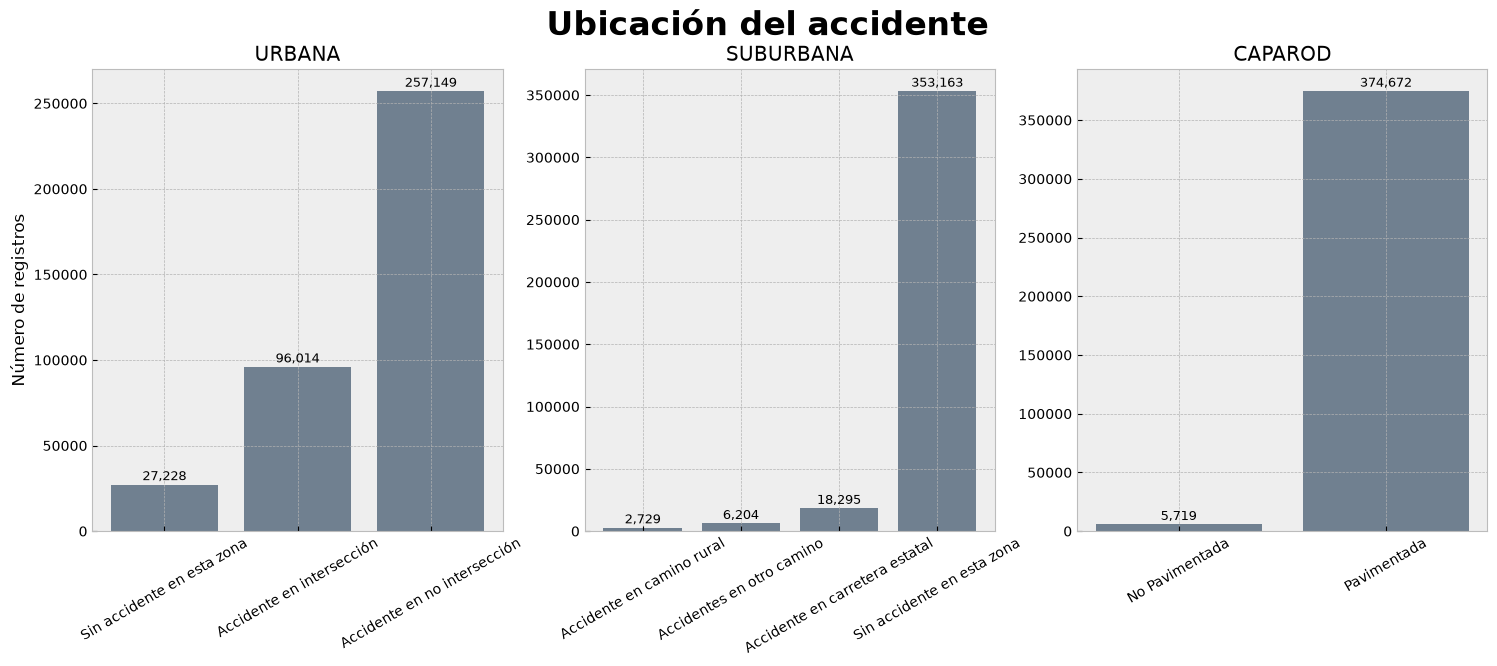

In [16]:
key = ['URBANA', 'SUBURBANA', 'CAPAROD']

with plt.style.context('bmh'):
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Ubicación del accidente', fontweight='bold', fontsize=24)
    ax[0].set_ylabel('Número de registros')
    for i in range(3):
    
        table = pd.DataFrame({key[i]: data_df.loc[:, key[i]].unique(),
                               'total': data_df.loc[:, key[i]].value_counts().values})
    
        table = table.sort_values('total', ascending=True)  
        
        ax[i].bar(table[key[i]], table['total'], color='slategrey')
        ax[i].set_title(key[i])
    
    
        for j, v in enumerate(table['total']):
            ax[i].text(j, v + max(table['total'])*0.01, f'{v:,}', ha='center', fontsize=9)
        ax[i].tick_params(axis='x', labelrotation=30)
        
    plt.show()

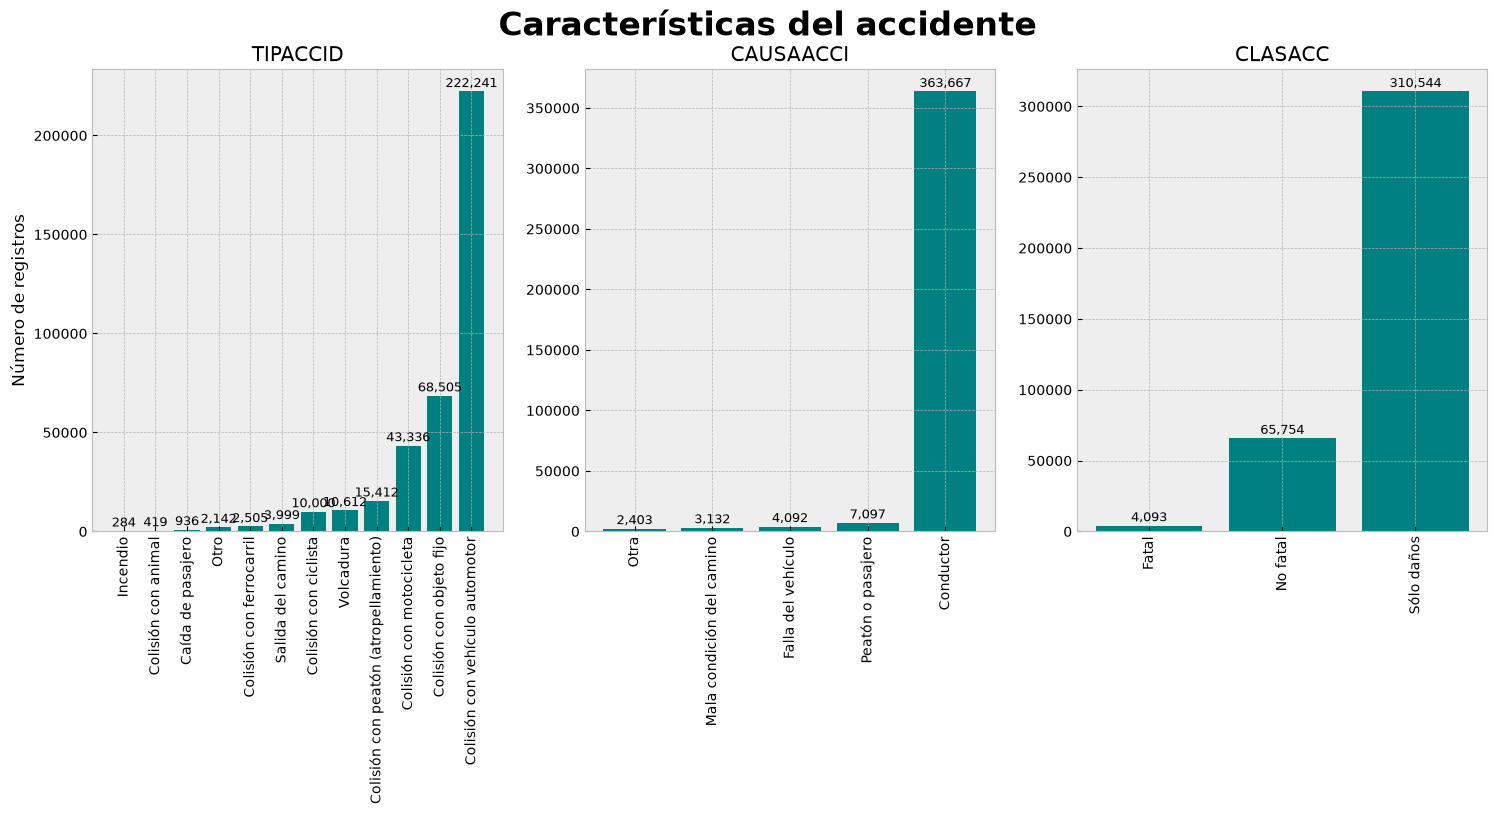

In [17]:
key = ['TIPACCID', 'CAUSAACCI', 'CLASACC']

with plt.style.context('bmh'):
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Características del accidente', fontweight='bold', fontsize=24)
    ax[0].set_ylabel('Número de registros')
    for i in range(3):
    
        table = pd.DataFrame({key[i]: data_df.loc[:, key[i]].unique(),
                               'total': data_df.loc[:, key[i]].value_counts().values})
    
        table = table.sort_values('total', ascending=True)  
        
        ax[i].bar(table[key[i]], table['total'], color='teal')
        ax[i].set_title(key[i])
    
    
        for j, v in enumerate(table['total']):
            ax[i].text(j, v + max(table['total'])*0.01, f'{v:,}', ha='center', fontsize=9)
        ax[i].tick_params(axis='x', labelrotation=90)
        
    plt.show()

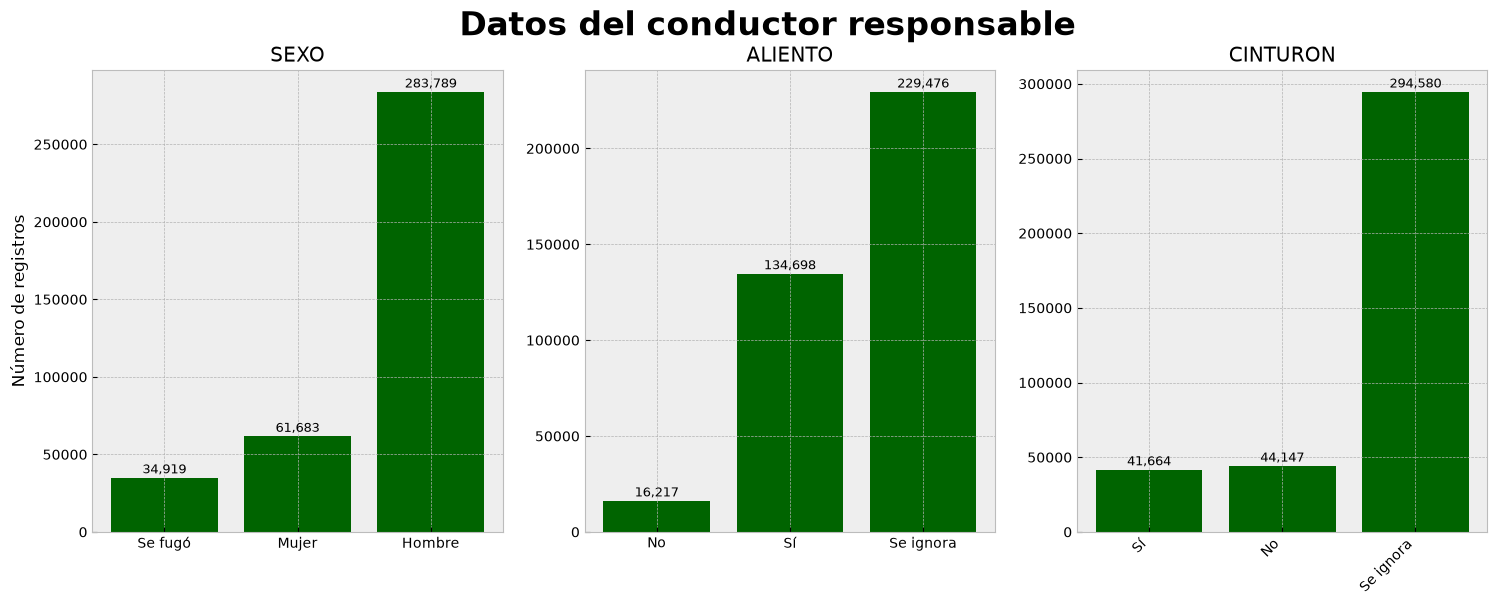

In [18]:
key = ['SEXO', 'ALIENTO', 'CINTURON']

with plt.style.context('bmh'):
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle('Datos del conductor responsable', fontweight='bold', fontsize=24)
    ax[0].set_ylabel('Número de registros')
    for i in range(3):
    
        table = pd.DataFrame({key[i]: data_df.loc[:, key[i]].unique(),
                               'total': data_df.loc[:, key[i]].value_counts().values})
    
        table = table.sort_values('total', ascending=True)  
        
        ax[i].bar(table[key[i]], table['total'], color='darkgreen')
        ax[i].set_title(key[i])
    
        plt.xticks(rotation=45, ha='right')
    
        for j, v in enumerate(table['total']):
            ax[i].text(j, v + max(table['total'])*0.01, f'{v:,}', ha='center', fontsize=9)
        
    plt.show()

In [19]:
map_tc_entidad = pd.read_csv('./catalogos/tc_entidad.csv')
map_tc_entidad = map_tc_entidad[['CVE_ENT','NOM_ENTIDAD']]
map_tc_entidad.head(2)

,CVE_ENT,NOM_ENTIDAD
0,1,Aguascalientes
1,2,Baja California


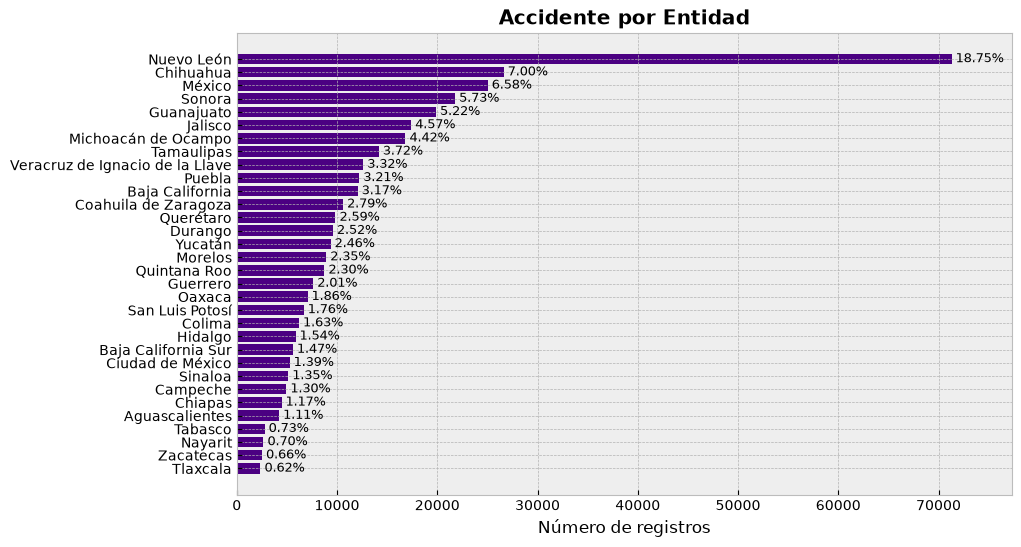

In [20]:
conteo_entidad = pd.DataFrame({ "conteo": data_df.groupby("CVE_ENT").size() })

mapping = map_tc_entidad.set_index('CVE_ENT')['NOM_ENTIDAD']
conteo_entidad['estado'] = conteo_entidad.index.map(mapping)

with plt.style.context('bmh'):
    fig, ax = plt.subplots(figsize=(10, 6))

    df_sorted = conteo_entidad.sort_values('conteo', ascending=True)

    ax.barh(df_sorted['estado'], df_sorted['conteo'], color='indigo')
    ax.set_xlabel('Número de registros')
    ax.set_title('Accidente por Entidad', fontweight='bold')

    total = np.sum(conteo_entidad['conteo'])
    
    for i, v in enumerate(df_sorted['conteo']):
        ax.text(v, i, f' {(v/total)*100:.2f}%', va='center', fontsize=9)

    ax.set_xlim(0, np.max(conteo_entidad['conteo']+6000))
    plt.show()

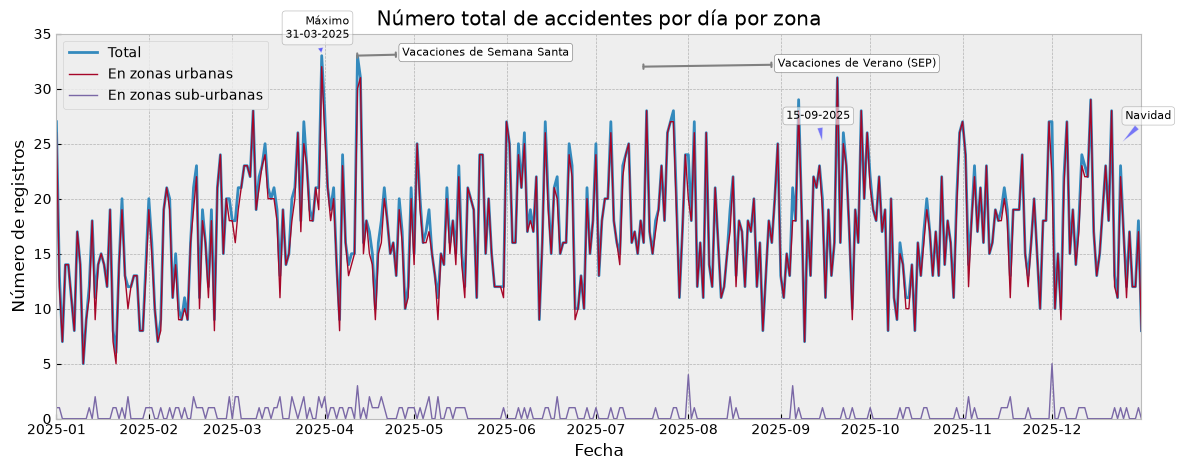

In [21]:
ar = 'Sin accidente en esta zona'
date_range = pd.date_range("2025-01-01", "2025-12-31", freq="D")

d_series = data_df.groupby("FECHA").size()
d_series = d_series.reindex(date_range, fill_value=0)

urbana_series = data_df[data_df["URBANA"] != ar].groupby("FECHA").size()
urbana_series = urbana_series.reindex(date_range, fill_value=0)
suburbana_series = data_df[data_df["SUBURBANA"] != ar].groupby("FECHA").size()
suburbana_series = suburbana_series.reindex(date_range, fill_value=0)

with plt.style.context('bmh'):
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(d_series.index, d_series.values, linewidth=2, label="Total")
    ax.plot(urbana_series.index, urbana_series.values, linewidth=1, label="En zonas urbanas")
    ax.plot(suburbana_series.index, suburbana_series.values, linewidth=1, label="En zonas sub-urbanas")
    ax.set_title("Número total de accidentes por día por zona")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Número de registros")

    ax.annotate(f"Vacaciones de Verano (SEP)", 
            xy=(pd.Timestamp('2025-07-16'),32), 
            xytext=(pd.Timestamp('2025-08-31'), 32),
            xycoords='data', textcoords='data',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9),
            arrowprops={'arrowstyle': '|-|,widthA=0.2,widthB=0.2', 
                        'color': 'grey',
                        'linewidth': 1.5},
            fontsize=8);

    ax.annotate(f"Vacaciones de Semana Santa", 
            xy=(pd.Timestamp('2025-04-11'), 33), 
            xytext=(pd.Timestamp('2025-04-27'), 33),
            xycoords='data', textcoords='data',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9),
            arrowprops={'arrowstyle': '|-|,widthA=0.2,widthB=0.2', 
                        'color': 'grey',
                        'linewidth': 1.5},
            fontsize=8)

    ax.annotate('Navidad', xy=(pd.Timestamp('2025-12-24'), 25),  xycoords='data',
             xytext=(20, 20), textcoords='offset points',
             size=8, ha='center', va="center",
             bbox=dict(boxstyle="round", alpha=0.5, fc="white", ec="gray"),
             arrowprops=dict(arrowstyle="wedge,tail_width=0.5", alpha=0.5));

    ax.annotate('15-09-2025', xy=(pd.Timestamp('2025-09-15'), 25),  xycoords='data',
             xytext=(20, 20), textcoords='offset points',
             size=8, ha='right', va="center",
             bbox=dict(boxstyle="round", alpha=0.6, fc="white", ec="gray"),
             arrowprops=dict(arrowstyle="wedge,tail_width=0.5", alpha=0.5));
    
    max_acc = d_series.idxmax()
    ts_max_str = max_acc.strftime('%d-%m-%Y') 
    
    ax.annotate(f'Máximo\n{ts_max_str}', xy=(max_acc, 33),  xycoords='data',
             xytext=(20, 20), textcoords='offset points',
             size=8, ha='right', va="center",
             bbox=dict(boxstyle="round", alpha=0.5, fc="white", ec="gray"),
             arrowprops=dict(arrowstyle="wedge,tail_width=0.5", alpha=0.6));

    ax.set_ylim(0, 35)
    ax.set_xlim(pd.Timestamp('2025-01-01'), pd.Timestamp('2025-12-31'))
    
    ax.legend(frameon=True)
    
    plt.show()

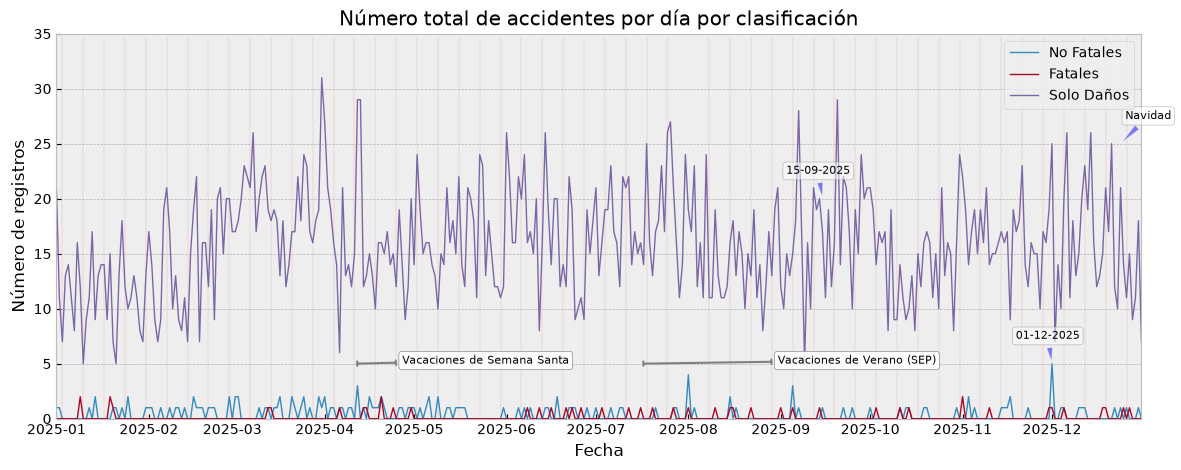

In [22]:
fatales_series = data_df[data_df["CLASACC"] == 'Fatal'].groupby("FECHA").size()
fatales_series = fatales_series.reindex(date_range, fill_value=0)
nofatales_series = data_df[data_df["CLASACC"] == 'No fatal'].groupby("FECHA").size()
nofatales_series = suburbana_series.reindex(date_range, fill_value=0)
danos_series = data_df[data_df["CLASACC"] == 'Sólo daños'].groupby("FECHA").size()
danos_series = danos_series.reindex(date_range, fill_value=0)


with plt.style.context('bmh'):
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(nofatales_series.index, nofatales_series.values, linewidth=1, label="No Fatales")
    ax.plot(fatales_series.index, fatales_series.values, linewidth=1, label="Fatales")
    ax.plot(danos_series.index, danos_series.values, linewidth=1, label="Solo Daños")
    ax.set_title("Número total de accidentes por día por clasificación")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Número de registros")
    
    ax.annotate(f"Vacaciones de Verano (SEP)", 
            xy=(pd.Timestamp('2025-07-16'),5), 
            xytext=(pd.Timestamp('2025-08-31'), 5),
            xycoords='data', textcoords='data',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9),
            arrowprops={'arrowstyle': '|-|,widthA=0.2,widthB=0.2', 
                        'color': 'grey',
                        'linewidth': 1.5},
            fontsize=8);

    ax.annotate(f"Vacaciones de Semana Santa", 
            xy=(pd.Timestamp('2025-04-11'), 5), 
            xytext=(pd.Timestamp('2025-04-27'), 5),
            xycoords='data', textcoords='data',
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.9),
            arrowprops={'arrowstyle': '|-|,widthA=0.2,widthB=0.2', 
                        'color': 'grey',
                        'linewidth': 1.5},
            fontsize=8)

    ax.annotate('Navidad', xy=(pd.Timestamp('2025-12-24'), 25),  xycoords='data',
             xytext=(20, 20), textcoords='offset points',
             size=8, ha='center', va="center",
             bbox=dict(boxstyle="round", alpha=0.5, fc="white", ec="gray"),
             arrowprops=dict(arrowstyle="wedge,tail_width=0.5", alpha=0.5));

    ax.annotate('15-09-2025', xy=(pd.Timestamp('2025-09-15'), 20),  xycoords='data',
             xytext=(20, 20), textcoords='offset points',
             size=8, ha='right', va="center",
             bbox=dict(boxstyle="round", alpha=0.5, fc="white", ec="gray"),
             arrowprops=dict(arrowstyle="wedge,tail_width=0.5", alpha=0.5));

    ax.annotate('01-12-2025', xy=(pd.Timestamp('2025-12-01'), 5),  xycoords='data',
             xytext=(20, 20), textcoords='offset points',
             size=8, ha='right', va="center",
             bbox=dict(boxstyle="round", alpha=0.5, fc="white", ec="gray"),
             arrowprops=dict(arrowstyle="wedge,tail_width=0.5", alpha=0.5));

    ax.xaxis.set_minor_locator(mp_dates.WeekdayLocator(byweekday=mp_dates.FR))
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())
    ax.tick_params(axis='x', which='minor', color = (1, 0, 0, 0.7), length=275, width=0.1, )
    ax.grid(which='major', axis='x', visible=False)
    
    ax.set_ylim(0, 35)
    ax.set_xlim(pd.Timestamp('2025-01-01'), pd.Timestamp('2025-12-31'))
    
    ax.legend(frameon=True)
    
    plt.show()

In [78]:
data_df_gravedad = data_df.copy()

In [79]:
mapa_gravedad = pd.DataFrame({'CLASACC': ['Sólo daños','No fatal','Fatal'], 'clave': [1, 2, 3]})
mapping = mapa_gravedad.set_index('CLASACC')['clave']

data_df_gravedad = data_df.copy()
data_df_gravedad['CLASACC'] = data_df_gravedad['CLASACC'].map(mapping)

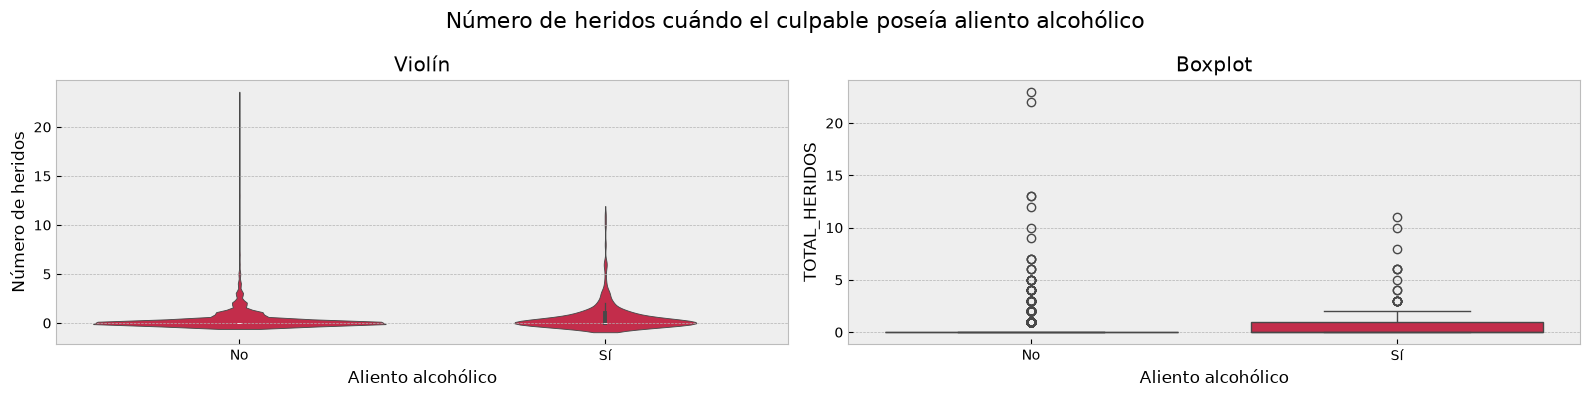

In [94]:
with plt.style.context('bmh'):
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))
    fig.suptitle('Número de heridos cuándo el culpable poseía aliento alcohólico', size=16)
    table = data_df_gravedad[(data_df_gravedad["CLASACC"] == 3) & (data_df_gravedad["ALIENTO"] != 'Se ignora')]
    aliento = table["ALIENTO"].value_counts().index

    sns.violinplot(data=table, x="ALIENTO", y="TOTAL_HERIDOS",
                   order=aliento, color='crimson', ax=axes[0])
    axes[0].set_xlabel("Aliento alcohólico")
    axes[0].set_ylabel("Número de heridos")
    axes[0].set_title("Violín")

    sns.boxplot(data=table, x="ALIENTO", y="TOTAL_HERIDOS",
                order=aliento, color='crimson', ax=axes[1])
    axes[1].set_xlabel("Aliento alcohólico")
    axes[1].set_title("Boxplot")

    plt.tight_layout()
    plt.show()

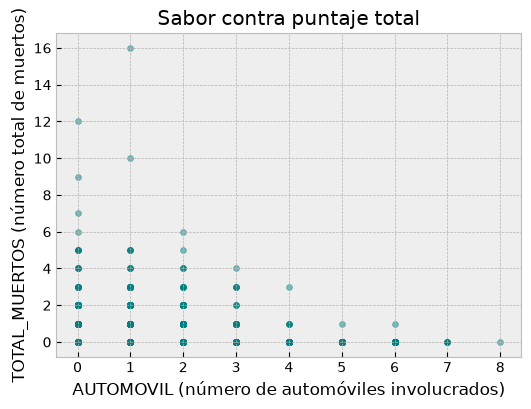

In [102]:
with plt.style.context('bmh'):
    fig, ax = plt.subplots(figsize=(6, 4.2))
    
    table = data_df_gravedad.copy()
    
    ax.scatter(table["AUTOMOVIL"], table["TOTAL_MUERTOS"],
               s=18, alpha=0.5, color='teal')
    
    ax.set_xlabel("AUTOMOVIL (número de automóviles involucrados)")
    ax.set_ylabel("TOTAL_MUERTOS (número total de muertos)")
    ax.set_title("Sabor contra puntaje total")
    plt.show()

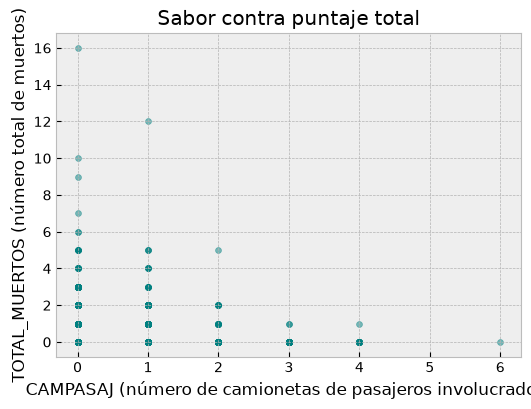

In [105]:
with plt.style.context('bmh'):
    fig, ax = plt.subplots(figsize=(6, 4.2))
    
    table = data_df_gravedad.copy()
    
    ax.scatter(table["CAMPASAJ"], table["TOTAL_MUERTOS"],
               s=18, alpha=0.5, color='teal')
    
    ax.set_xlabel("CAMPASAJ (número de camionetas de pasajeros involucrados)")
    ax.set_ylabel("TOTAL_MUERTOS (número total de muertos)")
    ax.set_title("Sabor contra puntaje total")
    plt.show()

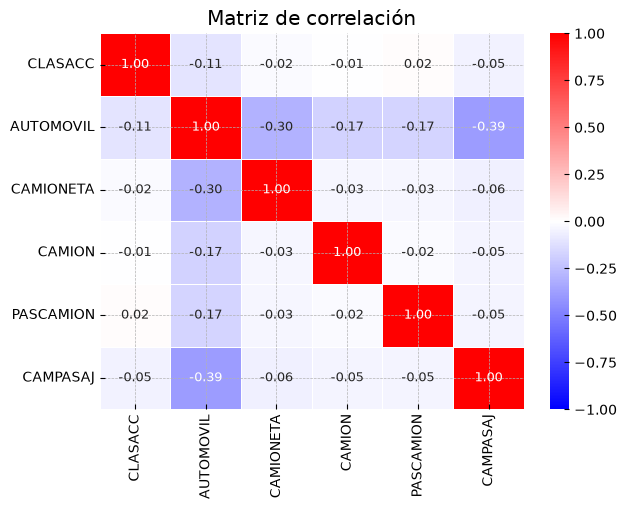

In [29]:
cols_vehiculo_selected = ['AUTOMOVIL', 'CAMIONETA', 'CAMION', 'PASCAMION', 'CAMPASAJ']

correlaciones = data_df_gravedad[
    ['CLASACC'] + cols_vehiculo_selected
].corr()

fig, ax = plt.subplots(figsize=(6.5, 5.2))

sns.heatmap(correlaciones, cmap="bwr", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".2f", annot_kws={"size": 9},
            linewidths=0.6, linecolor="white", ax=ax)

ax.set_title("Matriz de correlación")
plt.tight_layout()
plt.show()

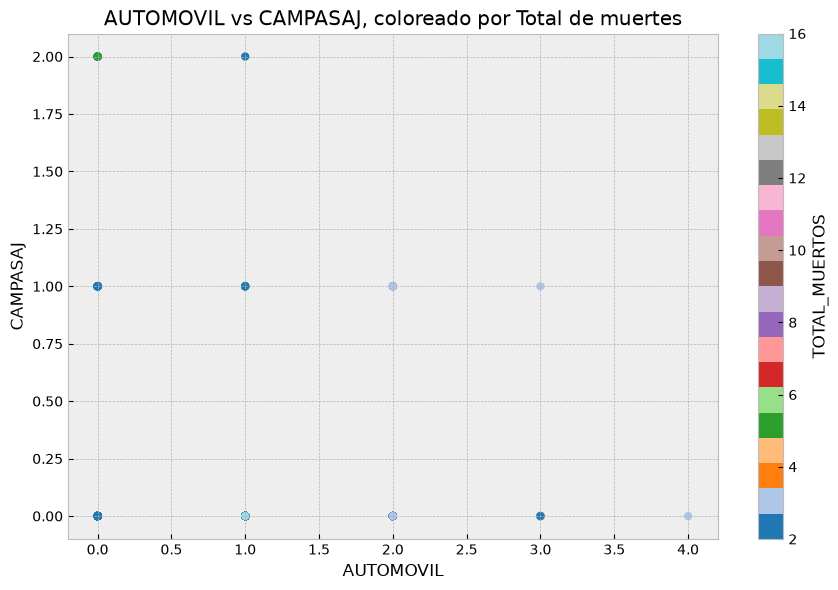

In [127]:
table = data_df_gravedad[(data_df_gravedad["TOTAL_MUERTOS"]>=2) &(data_df_gravedad["AUTOMOVIL"] >= 0) & (data_df_gravedad["CAMPASAJ"] >= 0)]

with plt.style.context('bmh'):
    fig, ax = plt.subplots(figsize=(9, 6))

    scatter = ax.scatter(
        table['AUTOMOVIL'],
        table['CAMPASAJ'],
        c=table['TOTAL_MUERTOS'],
        cmap='tab20',
        alpha=1,
        edgecolor='none'
    )

    ax.set_xlabel('AUTOMOVIL')
    ax.set_ylabel('CAMPASAJ')
    ax.set_title('AUTOMOVIL vs CAMPASAJ, coloreado por Total de muertes')

    cbar = fig.colorbar(scatter, ax=ax)
    cbar.set_label('TOTAL_MUERTOS')

    plt.tight_layout()
    plt.show()